In [1]:
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import rustworkx as rx
from rustworkx.visualization import mpl_draw

# Try to load FakeFez
try:
    from qiskit_ibm_runtime.fake_provider import FakeFez
    backend = FakeFez()
    print(f"✓ Loaded backend: {backend.name}")
    print(f"  Number of qubits: {backend.num_qubits}")
except ImportError as e:
    print(f"FakeFez not available: {e}")
    print("\nAvailable fake backends:")
    from qiskit_ibm_runtime import fake_provider
    backends = [name for name in dir(fake_provider) if name.startswith('Fake')]
    for b in sorted(backends):
        print(f"  - {b}")

✓ Loaded backend: fake_fez
  Number of qubits: 156


In [2]:
# Get coupling map and basic properties
coupling_map = backend.coupling_map
edges = list(coupling_map.get_edges())

print(f"=== {backend.name} Properties ===")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Number of edges (connections): {len(edges)}")

# Build adjacency list
adj = {i: set() for i in range(backend.num_qubits)}
for e in edges:
    adj[e[0]].add(e[1])
    adj[e[1]].add(e[0])

# Analyze connectivity
degrees = {i: len(adj[i]) for i in range(backend.num_qubits)}
print(f"\nConnectivity distribution:")
for deg in sorted(set(degrees.values())):
    count = sum(1 for d in degrees.values() if d == deg)
    qubits = [q for q, d in degrees.items() if d == deg]
    print(f"  Degree {deg}: {count} qubits")
    if count <= 20:
        print(f"    Qubits: {qubits}")

=== fake_fez Properties ===
Number of qubits: 156
Number of edges (connections): 352

Connectivity distribution:
  Degree 1: 8 qubits
    Qubits: [0, 20, 40, 60, 80, 100, 120, 140]
  Degree 2: 100 qubits
  Degree 3: 48 qubits


=== Coupling Map Visualization ===


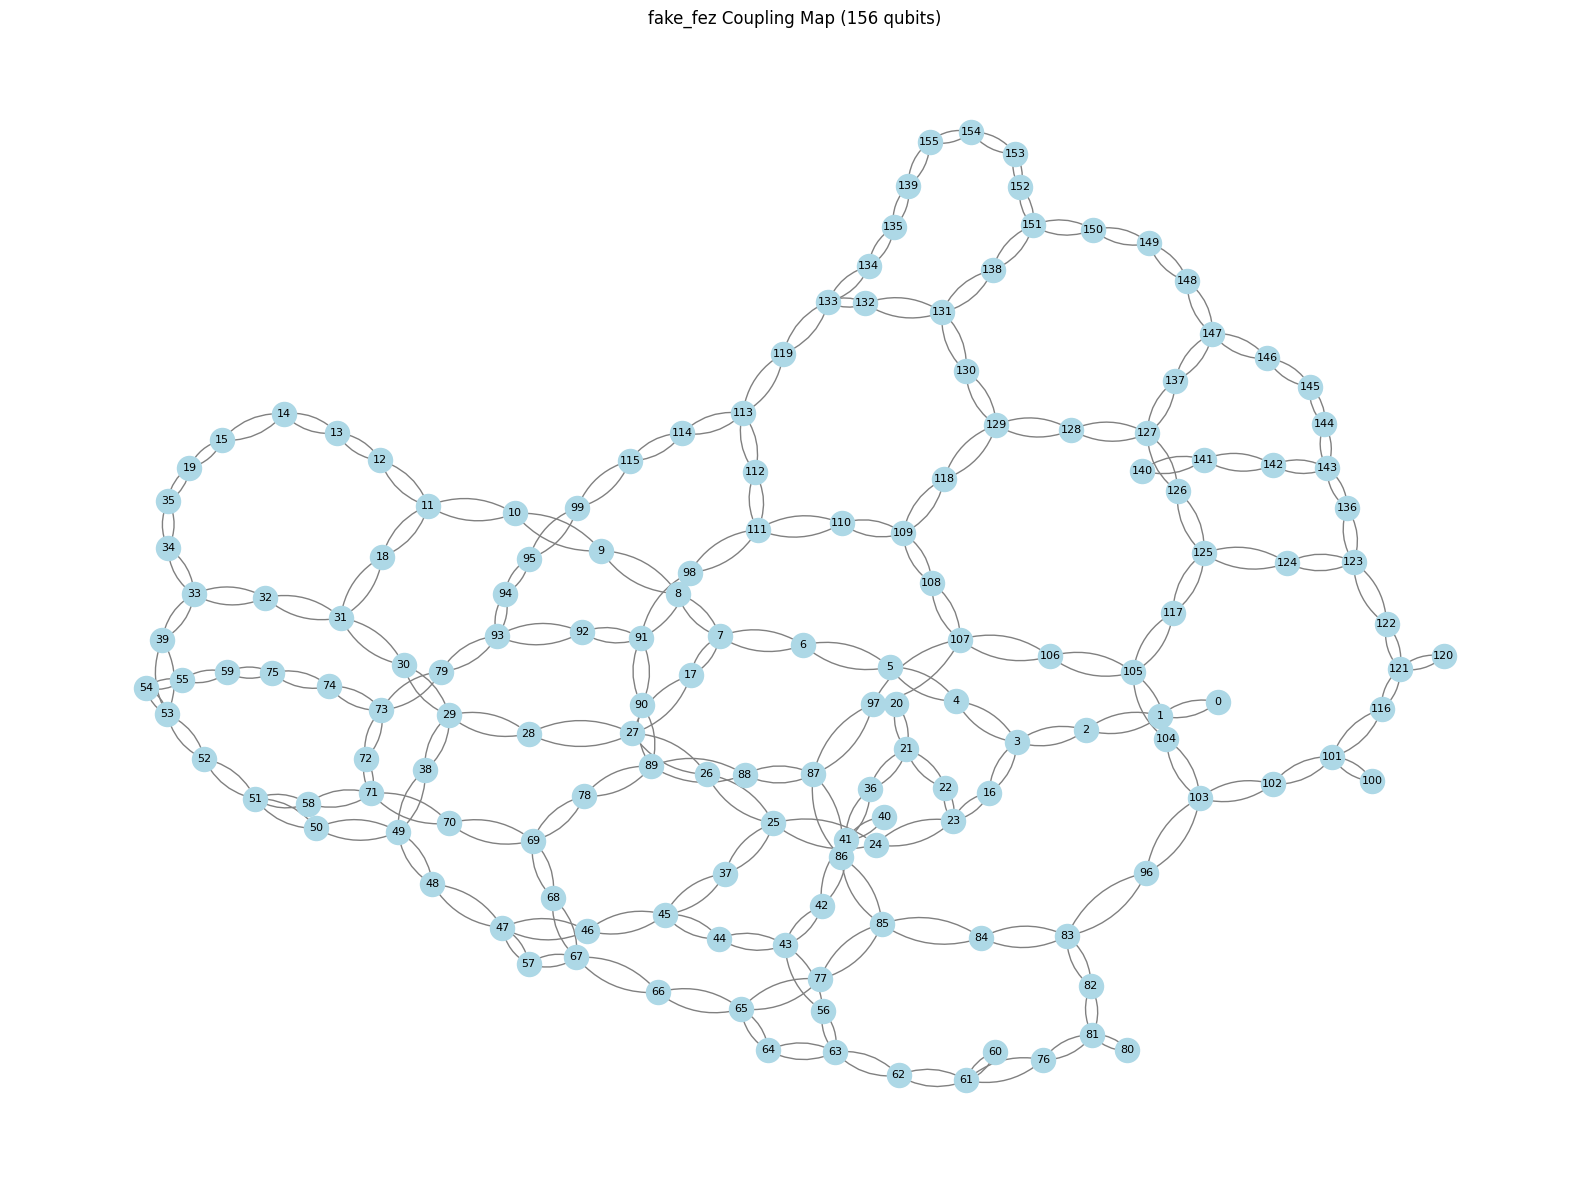

In [3]:
# Visualize the coupling map using rustworkx
print("=== Coupling Map Visualization ===")

# Create a graph from the coupling map
graph = rx.PyGraph()
graph.add_nodes_from(range(backend.num_qubits))
graph.add_edges_from_no_data(edges)

# Use spring layout for visualization
fig, ax = plt.subplots(figsize=(16, 12))
mpl_draw(graph, 
         ax=ax,
         with_labels=True,
         node_color='lightblue',
         node_size=300,
         font_size=8,
         edge_color='gray')
ax.set_title(f"{backend.name} Coupling Map ({backend.num_qubits} qubits)")
plt.tight_layout()
plt.show()

In [4]:
# Find all linear chains of 3 qubits (potential [[3,1,1]] clusters)
def find_linear_clusters(adj, num_qubits):
    """
    Find all linear 3-qubit chains: A - B - C where B connects to both A and C.
    Returns list of (top, center, bottom) tuples.
    """
    clusters = []
    for center in range(num_qubits):
        neighbors = list(adj[center])
        if len(neighbors) >= 2:
            # Try all pairs of neighbors
            for i in range(len(neighbors)):
                for j in range(i+1, len(neighbors)):
                    top, bottom = neighbors[i], neighbors[j]
                    # Ensure top < bottom for consistency
                    if top > bottom:
                        top, bottom = bottom, top
                    clusters.append((top, center, bottom))
    return clusters

clusters = find_linear_clusters(adj, backend.num_qubits)
print(f"Found {len(clusters)} potential [[3,1,1]] clusters (A-B-C patterns)")
print("\nFirst 20 clusters:")
for i, (top, center, bottom) in enumerate(clusters[:20]):
    print(f"  {i+1}. {top} - {center} - {bottom}")

Found 244 potential [[3,1,1]] clusters (A-B-C patterns)

First 20 clusters:
  1. 0 - 1 - 2
  2. 1 - 2 - 3
  3. 2 - 3 - 16
  4. 4 - 3 - 16
  5. 2 - 3 - 4
  6. 3 - 4 - 5
  7. 4 - 5 - 6
  8. 5 - 6 - 7
  9. 8 - 7 - 17
  10. 6 - 7 - 8
  11. 6 - 7 - 17
  12. 7 - 8 - 9
  13. 8 - 9 - 10
  14. 9 - 10 - 11
  15. 10 - 11 - 18
  16. 10 - 11 - 12
  17. 12 - 11 - 18
  18. 11 - 12 - 13
  19. 12 - 13 - 14
  20. 13 - 14 - 15


In [5]:
# Find clusters with potential syndrome ancillas
# For [[3,1,1]], we need ancillas adjacent to pairs of code qubits

def find_clusters_with_ancillas(adj, clusters):
    """
    Find clusters that have potential syndrome ancillas nearby.
    Ancilla for Z_top*Z_center needs to be adjacent to top (ideally both).
    Ancilla for Z_center*Z_bottom needs to be adjacent to bottom (ideally both).
    """
    valid_clusters = []
    
    for (top, center, bottom) in clusters:
        # Find potential ancillas for top pair (top-center)
        # Best: adjacent to both top and center
        # OK: adjacent to top only (can use SWAP-assisted)
        top_ancillas_direct = adj[top] & adj[center] - {top, center, bottom}
        top_ancillas_swap = adj[top] - {top, center, bottom}
        
        # Find potential ancillas for bottom pair (center-bottom)
        bot_ancillas_direct = adj[center] & adj[bottom] - {top, center, bottom}
        bot_ancillas_swap = adj[bottom] - {top, center, bottom}
        
        if top_ancillas_swap and bot_ancillas_swap:
            valid_clusters.append({
                'cluster': (top, center, bottom),
                'top_ancilla_direct': top_ancillas_direct,
                'top_ancilla_swap': top_ancillas_swap,
                'bot_ancilla_direct': bot_ancillas_direct,
                'bot_ancilla_swap': bot_ancillas_swap
            })
    
    return valid_clusters

valid_clusters = find_clusters_with_ancillas(adj, clusters)
print(f"Found {len(valid_clusters)} clusters with potential syndrome ancillas")
print("\nClusters with ancilla options (first 15):")
for i, vc in enumerate(valid_clusters[:15]):
    t, c, b = vc['cluster']
    print(f"  {i+1}. Cluster {t}-{c}-{b}:")
    print(f"      Top ancillas (direct): {vc['top_ancilla_direct'] or 'None'}")
    print(f"      Top ancillas (SWAP):   {vc['top_ancilla_swap']}")
    print(f"      Bot ancillas (direct): {vc['bot_ancilla_direct'] or 'None'}")
    print(f"      Bot ancillas (SWAP):   {vc['bot_ancilla_swap']}")

Found 230 clusters with potential syndrome ancillas

Clusters with ancilla options (first 15):
  1. Cluster 1-2-3:
      Top ancillas (direct): None
      Top ancillas (SWAP):   {0}
      Bot ancillas (direct): None
      Bot ancillas (SWAP):   {16, 4}
  2. Cluster 2-3-16:
      Top ancillas (direct): None
      Top ancillas (SWAP):   {1}
      Bot ancillas (direct): None
      Bot ancillas (SWAP):   {23}
  3. Cluster 4-3-16:
      Top ancillas (direct): None
      Top ancillas (SWAP):   {5}
      Bot ancillas (direct): None
      Bot ancillas (SWAP):   {23}
  4. Cluster 2-3-4:
      Top ancillas (direct): None
      Top ancillas (SWAP):   {1}
      Bot ancillas (direct): None
      Bot ancillas (SWAP):   {5}
  5. Cluster 3-4-5:
      Top ancillas (direct): None
      Top ancillas (SWAP):   {16, 2}
      Bot ancillas (direct): None
      Bot ancillas (SWAP):   {6}
  6. Cluster 4-5-6:
      Top ancillas (direct): None
      Top ancillas (SWAP):   {3}
      Bot ancillas (direct): None
  

In [6]:
# Find shortest paths between clusters for transport experiments
from collections import deque

def bfs_shortest_path(adj, start, end):
    """Find shortest path between two qubits using BFS."""
    if start == end:
        return [start]
    
    visited = {start}
    queue = deque([(start, [start])])
    
    while queue:
        node, path = queue.popleft()
        for neighbor in adj[node]:
            if neighbor == end:
                return path + [neighbor]
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

# Test path finding
if len(valid_clusters) >= 2:
    src_cluster = valid_clusters[0]['cluster']
    dst_cluster = valid_clusters[5]['cluster'] if len(valid_clusters) > 5 else valid_clusters[1]['cluster']
    
    path = bfs_shortest_path(adj, src_cluster[2], dst_cluster[2])  # bottom to bottom
    print(f"Example path from cluster {src_cluster} to {dst_cluster}:")
    print(f"  Bottom qubit path: {' → '.join(map(str, path))}")
    print(f"  Path length: {len(path)-1} hops")

Example path from cluster (1, 2, 3) to (4, 5, 6):
  Bottom qubit path: 3 → 4 → 5 → 6
  Path length: 3 hops


In [7]:
# Find all pairs of clusters and their path lengths
# We want to identify good candidates for SmallEdge (short) and LargeEdge (longer) paths

print("=== Analyzing Cluster Pairs for Transport Experiments ===")
print("Looking for pairs with different path lengths...\n")

# Sample clusters to analyze
sample_clusters = valid_clusters[:min(20, len(valid_clusters))]

path_info = []
for i, vc1 in enumerate(sample_clusters):
    for j, vc2 in enumerate(sample_clusters):
        if i >= j:
            continue
        
        src = vc1['cluster']
        dst = vc2['cluster']
        
        # Check if clusters don't share qubits
        if set(src) & set(dst):
            continue
        
        path = bfs_shortest_path(adj, src[2], dst[2])
        if path:
            path_len = len(path) - 1
            path_info.append({
                'src': src,
                'dst': dst,
                'path': path,
                'path_len': path_len,
                'src_ancillas': (list(vc1['top_ancilla_swap'])[0], list(vc1['bot_ancilla_swap'])[0]),
                'dst_ancillas': (list(vc2['top_ancilla_swap'])[0], list(vc2['bot_ancilla_swap'])[0])
            })

# Sort by path length
path_info.sort(key=lambda x: x['path_len'])

print(f"Found {len(path_info)} valid cluster pairs\n")

# Show shortest paths (SmallEdge candidates)
print("=== SHORT PATHS (SmallEdge candidates) ===")
for info in path_info[:5]:
    print(f"  Source: {info['src']} → Dest: {info['dst']}")
    print(f"  Path ({info['path_len']} hops): {' → '.join(map(str, info['path']))}")
    print(f"  Dst ancillas: {info['dst_ancillas']}")
    print()

# Show medium paths (LargeEdge candidates)
print("\n=== MEDIUM PATHS (LargeEdge candidates) ===")
mid_idx = len(path_info) // 2
for info in path_info[mid_idx:mid_idx+5]:
    print(f"  Source: {info['src']} → Dest: {info['dst']}")
    print(f"  Path ({info['path_len']} hops): {' → '.join(map(str, info['path']))}")
    print(f"  Dst ancillas: {info['dst_ancillas']}")
    print()

=== Analyzing Cluster Pairs for Transport Experiments ===
Looking for pairs with different path lengths...

Found 139 valid cluster pairs

=== SHORT PATHS (SmallEdge candidates) ===
  Source: (4, 5, 6) → Dest: (8, 7, 17)
  Path (2 hops): 6 → 7 → 17
  Dst ancillas: (9, 27)

  Source: (8, 9, 10) → Dest: (12, 11, 18)
  Path (2 hops): 10 → 11 → 18
  Dst ancillas: (13, 31)

  Source: (1, 2, 3) → Dest: (4, 5, 6)
  Path (3 hops): 3 → 4 → 5 → 6
  Dst ancillas: (3, 7)

  Source: (2, 3, 4) → Dest: (5, 6, 7)
  Path (3 hops): 4 → 5 → 6 → 7
  Dst ancillas: (4, 8)

  Source: (3, 4, 5) → Dest: (8, 7, 17)
  Path (3 hops): 5 → 6 → 7 → 17
  Dst ancillas: (9, 27)


=== MEDIUM PATHS (LargeEdge candidates) ===
  Source: (6, 7, 8) → Dest: (12, 13, 14)
  Path (6 hops): 8 → 9 → 10 → 11 → 12 → 13 → 14
  Dst ancillas: (11, 15)

  Source: (6, 7, 17) → Dest: (10, 11, 18)
  Path (6 hops): 17 → 27 → 28 → 29 → 30 → 31 → 18
  Dst ancillas: (9, 31)

  Source: (6, 7, 17) → Dest: (10, 11, 12)
  Path (6 hops): 17 → 7 → 8

In [8]:
# Select specific clusters for our experiments
# Based on the analysis above, let's pick good candidates

print("=== SELECTED CONFIGURATIONS ===")

if len(path_info) >= 2:
    # SmallEdge: shortest path
    small_edge = path_info[0]
    print("\n--- SMALL EDGE ---")
    print(f"Source cluster: {small_edge['src']}")
    print(f"Destination cluster: {small_edge['dst']}")
    print(f"Travel path: {small_edge['path'][1:-1]}")
    print(f"Path length: {small_edge['path_len']} hops")
    print(f"Destination ancillas: {small_edge['dst_ancillas']}")
    
    # Calculate SWAPs
    n = small_edge['path_len']
    small_swaps = n + (n+1) + (n+2)
    print(f"Estimated total SWAPs: {small_swaps} ({n} + {n+1} + {n+2})")
    
    # LargeEdge: longer path
    large_idx = min(len(path_info)-1, max(5, len(path_info)//2))
    large_edge = path_info[large_idx]
    print("\n--- LARGE EDGE ---")
    print(f"Source cluster: {large_edge['src']}")
    print(f"Destination cluster: {large_edge['dst']}")
    print(f"Travel path: {large_edge['path'][1:-1]}")
    print(f"Path length: {large_edge['path_len']} hops")
    print(f"Destination ancillas: {large_edge['dst_ancillas']}")
    
    n = large_edge['path_len']
    large_swaps = n + (n+1) + (n+2)
    print(f"Estimated total SWAPs: {large_swaps} ({n} + {n+1} + {n+2})")
else:
    print("Not enough valid cluster pairs found!")

=== SELECTED CONFIGURATIONS ===

--- SMALL EDGE ---
Source cluster: (4, 5, 6)
Destination cluster: (8, 7, 17)
Travel path: [7]
Path length: 2 hops
Destination ancillas: (9, 27)
Estimated total SWAPs: 9 (2 + 3 + 4)

--- LARGE EDGE ---
Source cluster: (6, 7, 8)
Destination cluster: (12, 13, 14)
Travel path: [9, 10, 11, 12, 13]
Path length: 6 hops
Destination ancillas: (11, 15)
Estimated total SWAPs: 21 (6 + 7 + 8)


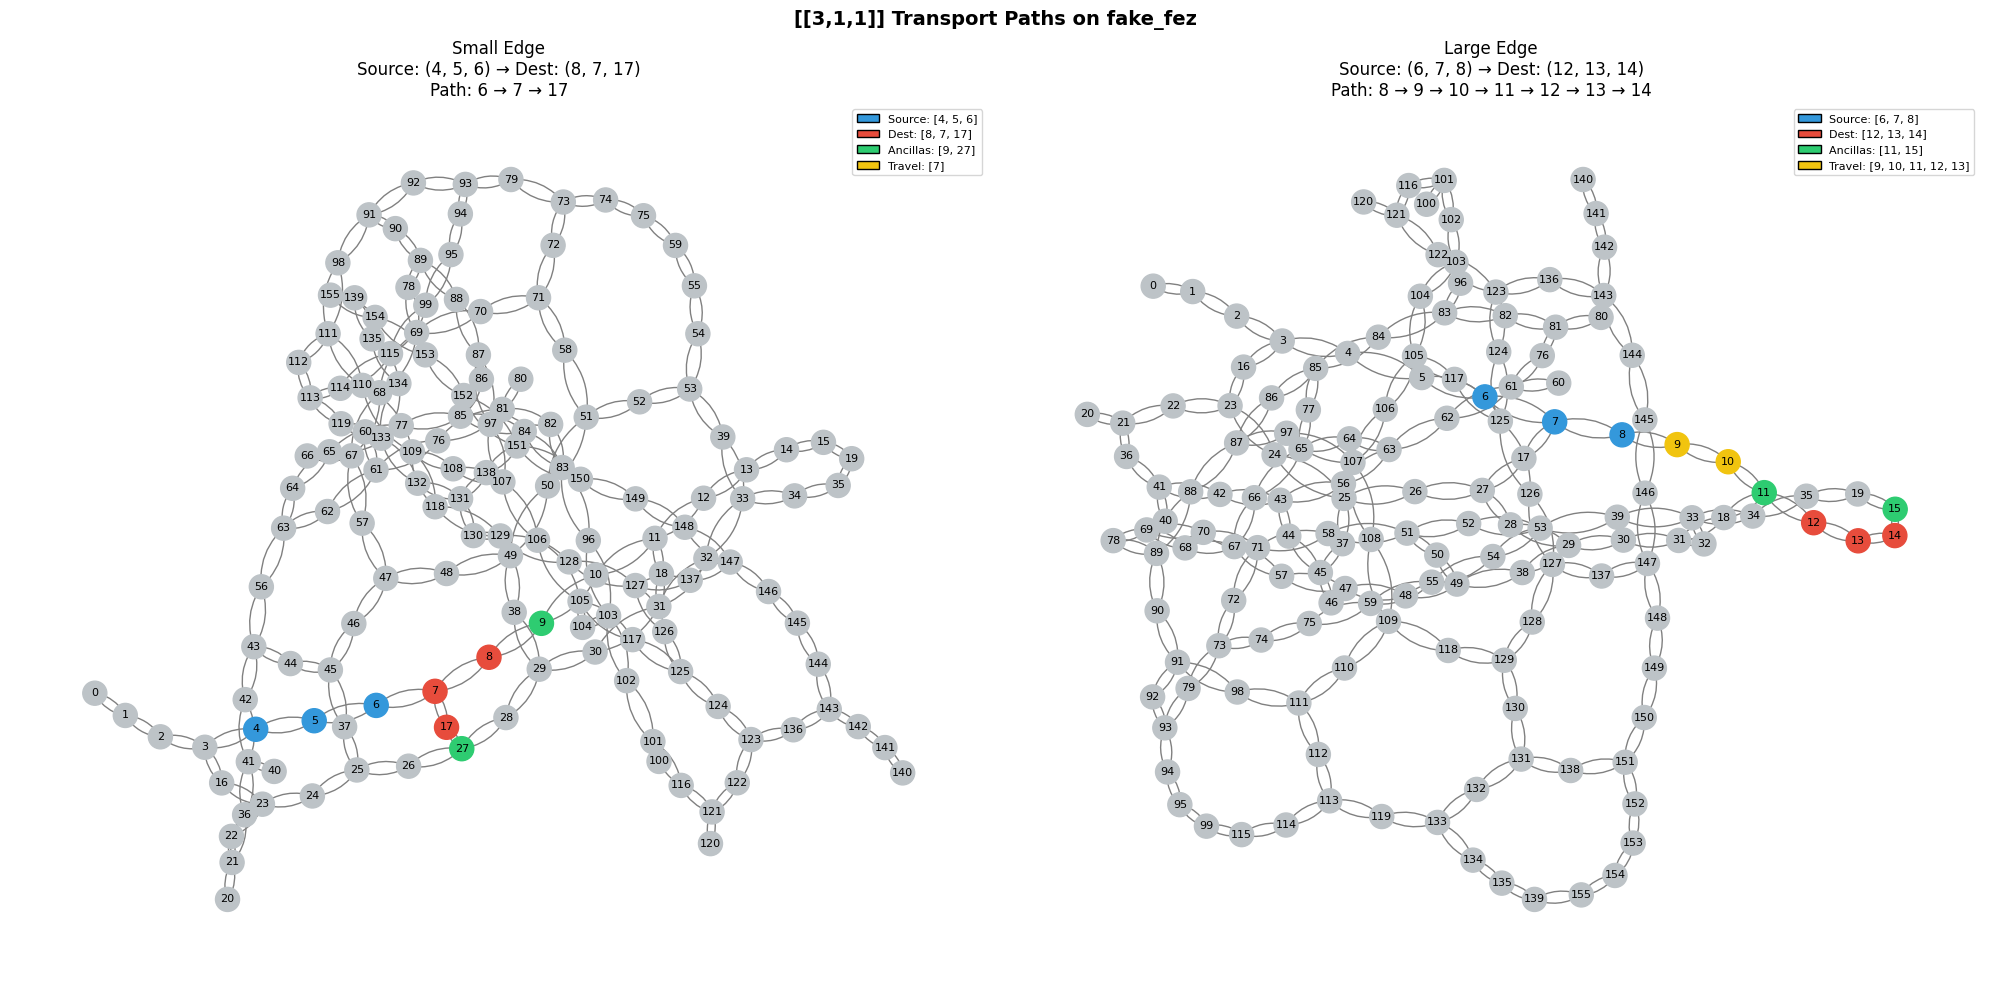

In [9]:
# Visualize the selected paths on the topology
if len(path_info) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for ax_idx, (edge_info, title) in enumerate([
        (small_edge, "Small Edge"),
        (large_edge, "Large Edge")
    ]):
        ax = axes[ax_idx]
        
        src = edge_info['src']
        dst = edge_info['dst']
        path = edge_info['path']
        dst_anc = edge_info['dst_ancillas']
        
        # Color nodes
        node_colors = []
        for i in range(backend.num_qubits):
            if i in src:
                node_colors.append('#3498db')  # Blue - Source
            elif i in dst:
                node_colors.append('#e74c3c')  # Red - Destination
            elif i in dst_anc:
                node_colors.append('#2ecc71')  # Green - Ancillas
            elif i in path[1:-1]:
                node_colors.append('#f1c40f')  # Yellow - Travel path
            else:
                node_colors.append('#bdc3c7')  # Gray
        
        mpl_draw(graph,
                 ax=ax,
                 with_labels=True,
                 node_color=node_colors,
                 node_size=300,
                 font_size=8,
                 edge_color='gray')
        
        ax.set_title(f"{title}\nSource: {src} → Dest: {dst}\nPath: {' → '.join(map(str, path))}")
        
        # Add legend
        legend_elements = [
            Patch(facecolor='#3498db', edgecolor='black', label=f'Source: {list(src)}'),
            Patch(facecolor='#e74c3c', edgecolor='black', label=f'Dest: {list(dst)}'),
            Patch(facecolor='#2ecc71', edgecolor='black', label=f'Ancillas: {list(dst_anc)}'),
            Patch(facecolor='#f1c40f', edgecolor='black', label=f'Travel: {path[1:-1]}')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    plt.suptitle(f"[[3,1,1]] Transport Paths on {backend.name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [10]:
# Print final configuration for use in experiment notebook
print("="*70)
print("FINAL CONFIGURATION FOR FakeFez TRANSPORT EXPERIMENTS")
print("="*70)

if len(path_info) >= 2:
    print("\n# --- SMALL EDGE CONFIGURATION ---")
    print(f"source_qubits_small = {list(small_edge['src'])}  # [top, data, bottom]")
    print(f"dest_qubits_small = {list(small_edge['dst'])}  # [top', data', bottom']")
    print(f"ancilla_qubits_small = {list(small_edge['dst_ancillas'])}  # [top_ancilla, bottom_ancilla]")
    travel_small = small_edge['path'][1:-1]
    print(f"travel_path_small = {travel_small}")
    
    print("\n# --- LARGE EDGE CONFIGURATION ---")
    print(f"source_qubits_large = {list(large_edge['src'])}  # [top, data, bottom]")
    print(f"dest_qubits_large = {list(large_edge['dst'])}  # [top', data', bottom']")
    print(f"ancilla_qubits_large = {list(large_edge['dst_ancillas'])}  # [top_ancilla, bottom_ancilla]")
    travel_large = large_edge['path'][1:-1]
    print(f"travel_path_large = {travel_large}")
    
    print("\n" + "="*70)
    print("Copy the above configuration to the experiment notebook!")
    print("="*70)

FINAL CONFIGURATION FOR FakeFez TRANSPORT EXPERIMENTS

# --- SMALL EDGE CONFIGURATION ---
source_qubits_small = [4, 5, 6]  # [top, data, bottom]
dest_qubits_small = [8, 7, 17]  # [top', data', bottom']
ancilla_qubits_small = [9, 27]  # [top_ancilla, bottom_ancilla]
travel_path_small = [7]

# --- LARGE EDGE CONFIGURATION ---
source_qubits_large = [6, 7, 8]  # [top, data, bottom]
dest_qubits_large = [12, 13, 14]  # [top', data', bottom']
ancilla_qubits_large = [11, 15]  # [top_ancilla, bottom_ancilla]
travel_path_large = [9, 10, 11, 12, 13]

Copy the above configuration to the experiment notebook!
